# A first linear regression: weather and NOx

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/regression/01-weather-and-nox.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

A gas-turbine operator cannot choose tomorrow's weather, but they can observe a weather forecast before deciding how to schedule the plant. This notebook asks a deliberately simple question:

> **How is the NOx concentration observed at the plant associated with ambient temperature?**

The result will be useful for learning linear regression and statistical inference. It is not a complete physical model of the turbine, and it does not tell us what would happen if we intervened to change the ambient temperature.

**Learning objectives**

- Define a response variable and a predictor for a regression question.
- Fit and visualize a least-squares line.
- Interpret a slope, confidence interval, and p-value.
- Distinguish statistical evidence for an association from causal evidence or a complete predictive model.

## 1. Load the course dataset

The Foundations notebooks introduced this hourly gas-turbine dataset. We repeat the setup here so that this notebook runs independently in Colab. The two variables needed for this first model are:

- `AT`: ambient temperature in °C
- `NOX`: NOx concentration in mg/m³

Each row is an hourly aggregate of plant measurements.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from urllib.request import urlretrieve

# Use a consistent visual style across the course notebooks.
plt.style.use("seaborn-v0_8-whitegrid")

# Point to the documented course version, rather than a changing external source.
DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-course.csv"
)
data_path = next(
    (path for path in [
        Path("../data/gas-turbine-course.csv"),
        Path("site/data/gas-turbine-course.csv"),
        Path("gas-turbine-course.csv"),
    ] if path.exists()),
    Path("gas-turbine-course.csv"),
)
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)
data[["AT", "NOX"]].head()

,AT,NOX
0,4.5878,81.952
1,4.2932,82.377
2,3.9045,83.776
3,3.7436,82.505
4,3.7516,82.028


## 2. State the model

We treat NOx concentration as the response, \(Y\), and ambient temperature as the predictor, \(X\):\n
\[
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i.
\]

For this notebook, that becomes:

\[
\mathrm{NOx}_i = \beta_0 + \beta_1\,\mathrm{AT}_i + \varepsilon_i.
\]

The error term, \(\varepsilon_i\), represents everything this one-variable line does not capture: other operating conditions, measurement variation, and features not recorded in the data.

In [2]:
# Keep only the variables for this first model and remove rows missing either value.
regression_data = data[["AT", "NOX"]].dropna()
print(f"Observations used: {len(regression_data):,}")
regression_data.describe()

Observations used: 36,733


,AT,NOX
count,36733.000000,36733.000000
mean,17.712726,65.293067
std,7.447451,11.678357
min,-6.234800,25.905000
25%,11.781000,57.162000
50%,17.801000,63.849000
75%,23.665000,71.548000
max,37.103000,119.910000


## 3. Look before fitting

A scatterplot lets us see the relationship before asking a model to summarize it. We plot a fixed subset only to keep the figure legible; the fitted model below will use every available observation.

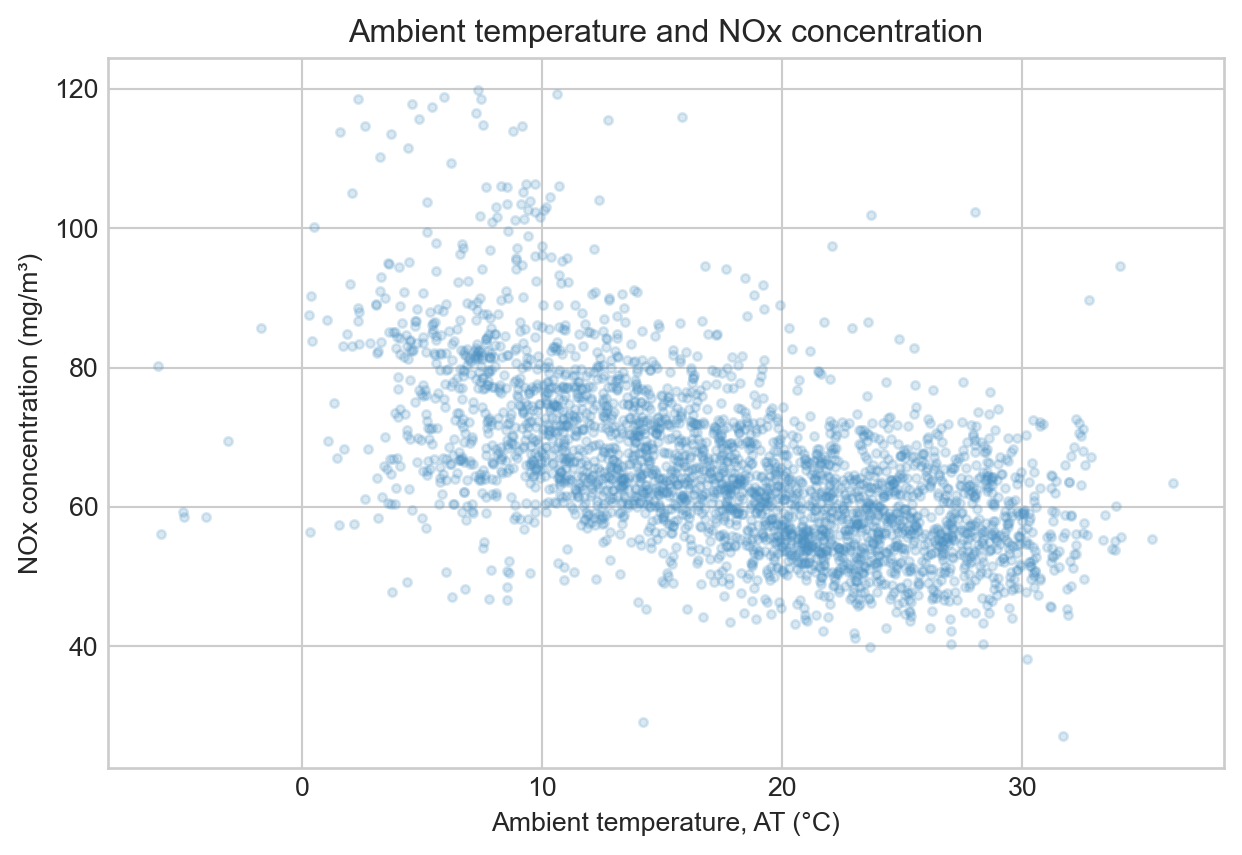

In [3]:
# A fixed subset makes a dense scatterplot readable and reproducible.
plot_data = regression_data.sample(n=3_000, random_state=4520)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(plot_data["AT"], plot_data["NOX"], alpha=0.2, s=10, color="#4a90c2")
ax.set(
    xlabel="Ambient temperature, AT (°C)",
    ylabel="NOx concentration (mg/m³)",
    title="Ambient temperature and NOx concentration",
)
plt.show()

The cloud slopes downward, but it is far from a perfect line. That is normal: a useful first regression model can leave substantial variation unexplained.

## 4. Fit the least-squares line

`statsmodels` fits the line and provides the inferential quantities that we will use later: standard errors, confidence intervals, and p-values. Adding a constant column lets the model estimate the intercept, \(\beta_0\).

In [4]:
# statsmodels expects us to add the intercept column explicitly.
X = sm.add_constant(regression_data["AT"])
y = regression_data["NOX"]
model = sm.OLS(y, X).fit()

coefficient_table = pd.DataFrame({
    "estimate": model.params,
    "standard error": model.bse,
    "p-value": model.pvalues,
})
coefficient_table.index = ["intercept", "AT"]
coefficient_table

,estimate,standard error,p-value
intercept,80.796532,0.130444,0.0
AT,-0.875273,0.006789,0.0


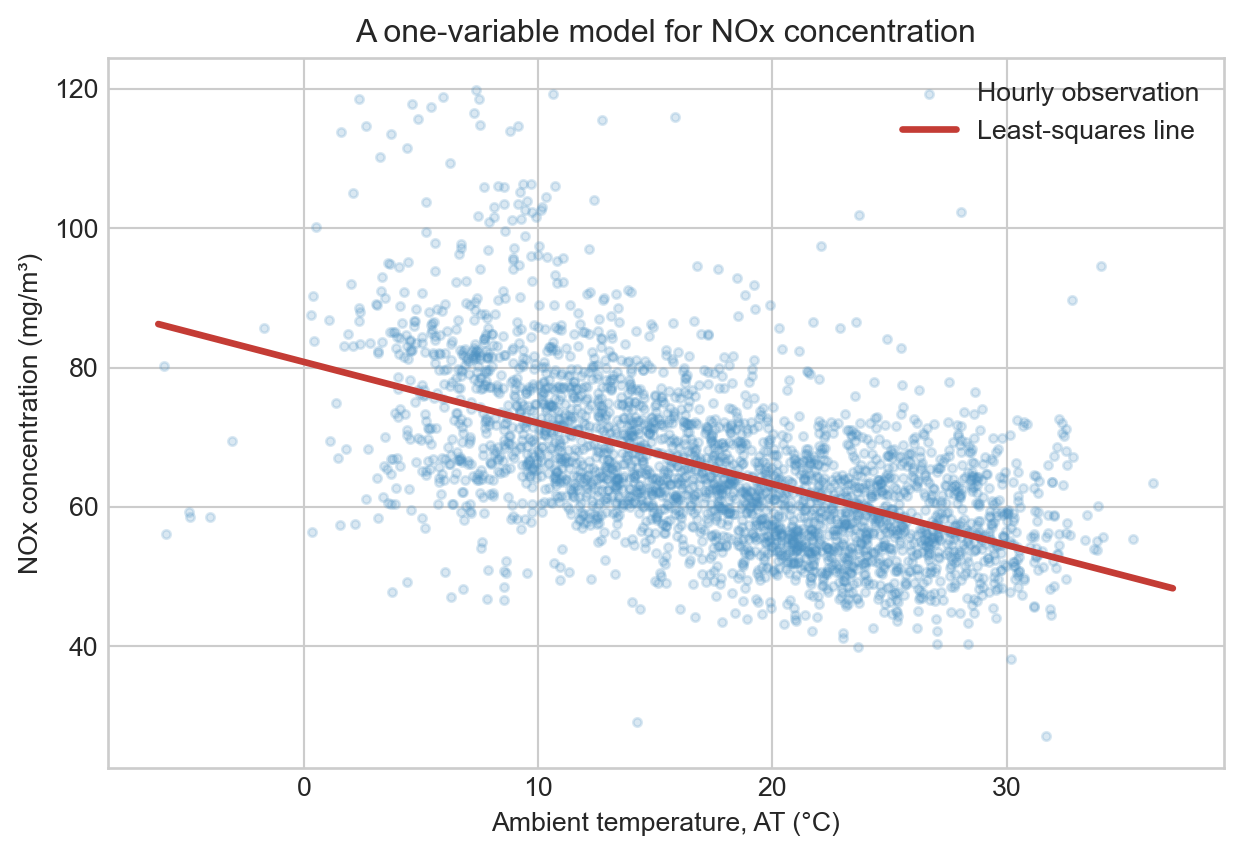

Fitted line: NOx = 80.80 -0.875 × AT
R²: 0.312


In [5]:
intercept = model.params["const"]
slope = model.params["AT"]
temperature_grid = np.linspace(regression_data["AT"].min(), regression_data["AT"].max(), 200)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(plot_data["AT"], plot_data["NOX"], alpha=0.2, s=10, color="#4a90c2", label="Hourly observation")
ax.plot(
    temperature_grid,
    intercept + slope * temperature_grid,
    color="#c43c35",
    linewidth=2.5,
    label="Least-squares line",
)
ax.set(
    xlabel="Ambient temperature, AT (°C)",
    ylabel="NOx concentration (mg/m³)",
    title="A one-variable model for NOx concentration",
)
ax.legend()
plt.show()

print(f"Fitted line: NOx = {intercept:.2f} {slope:+.3f} × AT")
print(f"R²: {model.rsquared:.3f}")

### Interpret the slope

The fitted slope is the predicted difference in NOx concentration associated with a one-degree-Celsius difference in ambient temperature. In this dataset, the fitted line slopes downward.

This is an **association**, not an intervention claim. We have not randomly assigned a plant to different weather conditions, and other features of plant operation can differ between hot and cool hours.

## 5. Is the association statistically distinguishable from zero?

For the slope, the conventional null hypothesis is:

\[
H_0: \beta_1 = 0.
\]

Under this null model, ambient temperature has no linear association with the population mean NOx concentration. The p-value asks: **if that null model were true, how surprising would a slope at least this far from zero be?**

In [6]:
# A 95% confidence interval for the population slope.
slope_interval = model.conf_int().loc["AT"]
slope_p_value = model.pvalues["AT"]

print(f"Estimated slope: {slope:.3f} mg/m³ per °C")
print(f"95% confidence interval: [{slope_interval.iloc[0]:.3f}, {slope_interval.iloc[1]:.3f}] mg/m³ per °C")
if slope_p_value == 0:
    print("p-value: smaller than 1e-300 (below numerical precision)")
else:
    print(f"p-value: {slope_p_value:.3e}")

Estimated slope: -0.875 mg/m³ per °C
95% confidence interval: [-0.889, -0.862] mg/m³ per °C
p-value: smaller than 1e-300 (below numerical precision)


With tens of thousands of observations, the p-value is extremely small and the confidence interval is narrow. This is strong evidence against a zero *linear association* in the historical data.

It does **not** establish that changing ambient temperature would cause the corresponding change in NOx. It also does not mean this one-variable model explains every high- or low-emission hour. The model's \(R^2\) tells us what fraction of observed NOx variation is summarized by this line.

## Check-in

1. Use the fitted slope to estimate the predicted difference in NOx concentration between a 10 °C and a 20 °C hour.
2. Does the very small p-value show that ambient temperature *causes* the observed difference? Why not?
3. If the model's \(R^2\) is about 0.31, what does that suggest about the remaining variation in NOx?\n
Keep your answers in your own notes. Later regression materials will add predictors, examine residuals, and test how well models generalize to new periods.

[Return to the Regression page](index.qmd)